In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better chart style
plt.style.use("ggplot")

# Load cleaned dataset
df = pd.read_csv("netflix_cleaned.csv")

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

   date_added  release_year rating   duration  \
0  2021-09-25          2020  PG-13     90 min   
1  2021-09-24          2021  TV-MA  2 Seasons   
2  2021-09-24          2021  TV-MA   1 Season   
3  2

In [5]:
import os

os.makedirs("../images", exist_ok=True)

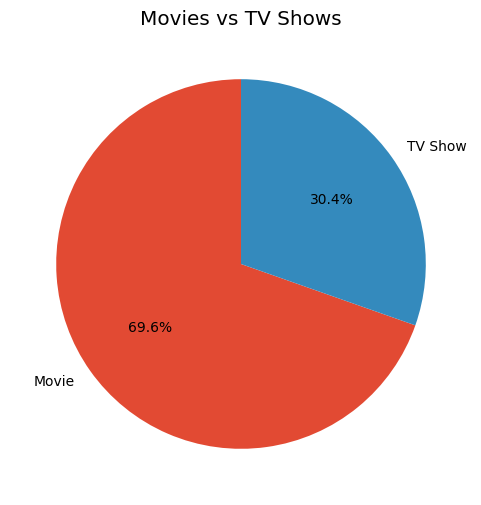

In [7]:
plt.figure(figsize=(6,6))

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows")

plt.ylabel("")

plt.savefig("../images/01_movies_vs_tvshows.png", dpi=300)

plt.show()

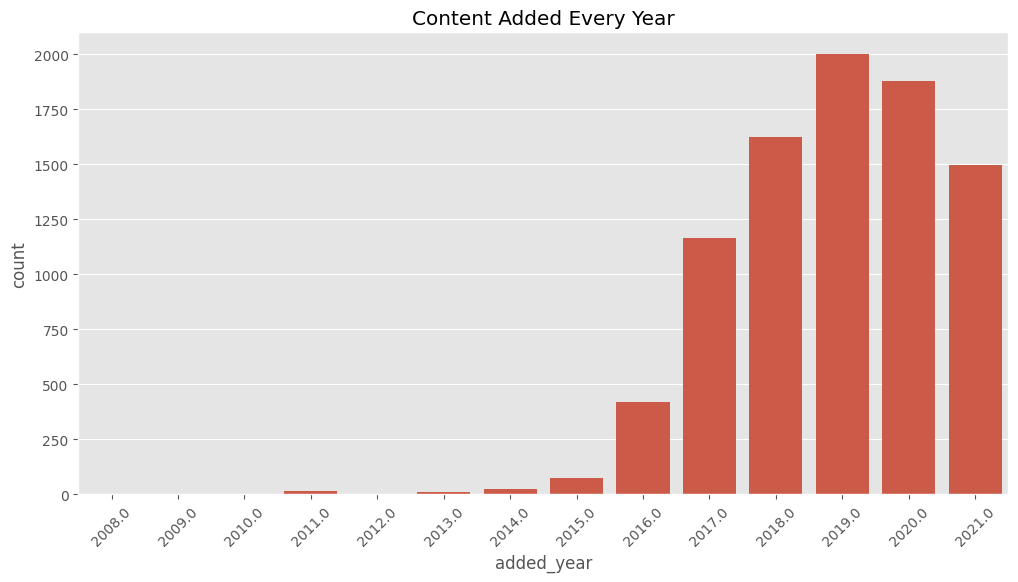

In [8]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="added_year",
    order=df["added_year"].value_counts().sort_index().index
)

plt.xticks(rotation=45)

plt.title("Content Added Every Year")

plt.savefig("../images/02_added_per_year.png", dpi=300)

plt.show()

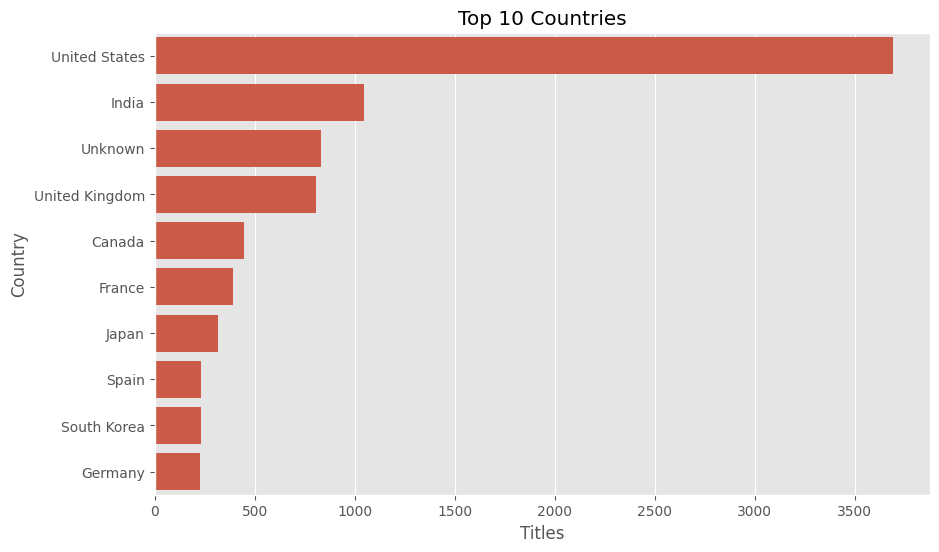

In [9]:
country = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_country = country.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_country.values,
    y=top_country.index
)

plt.title("Top 10 Countries")

plt.xlabel("Titles")

plt.ylabel("Country")

plt.savefig("../images/03_top_countries.png", dpi=300)

plt.show()


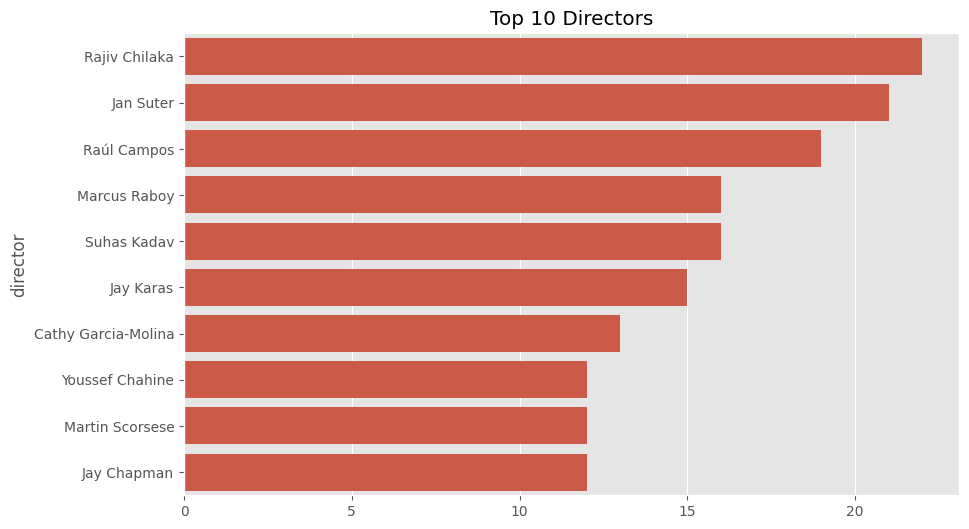

In [10]:
director = (
    df[df["director"] != "Unknown"]["director"]
    .str.split(", ")
    .explode()
)

top_director = director.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_director.values,
    y=top_director.index
)

plt.title("Top 10 Directors")

plt.savefig("../images/04_top_directors.png", dpi=300)

plt.show()

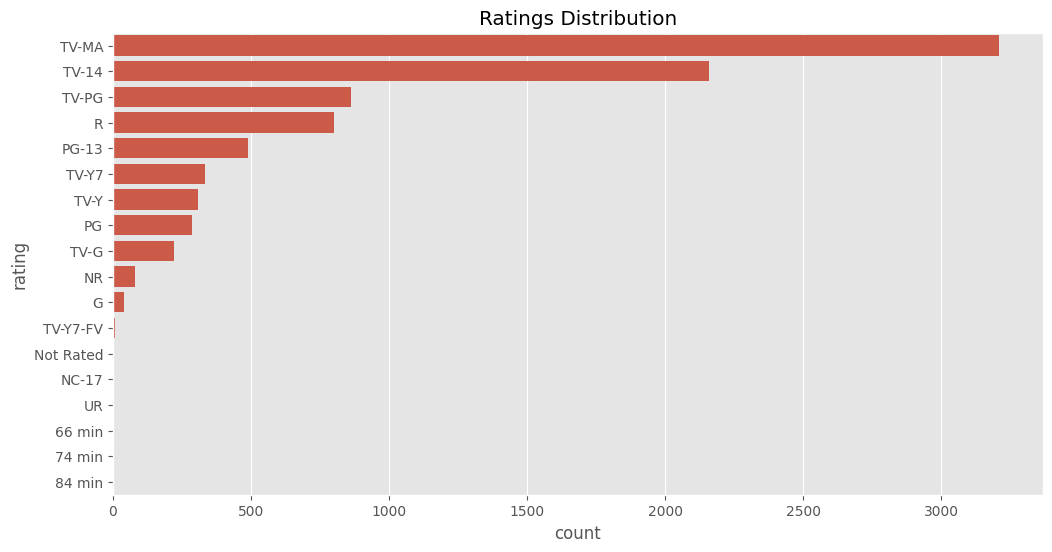

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)

plt.title("Ratings Distribution")

plt.savefig("../images/05_ratings.png", dpi=300)

plt.show()

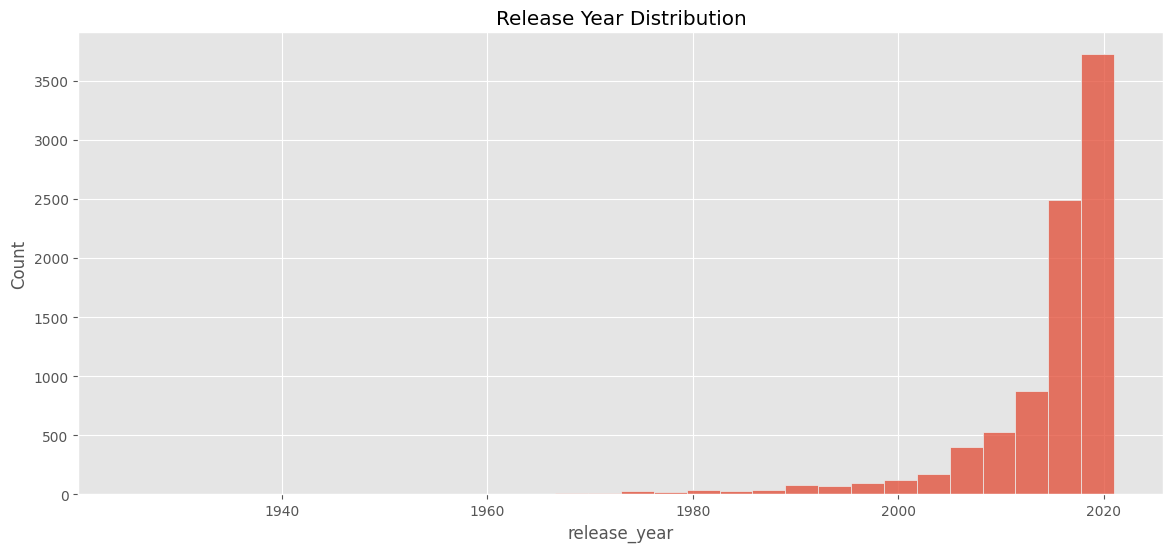

In [12]:
plt.figure(figsize=(14,6))

sns.histplot(
    df["release_year"],
    bins=30
)

plt.title("Release Year Distribution")

plt.savefig("../images/06_release_year.png", dpi=300)

plt.show()


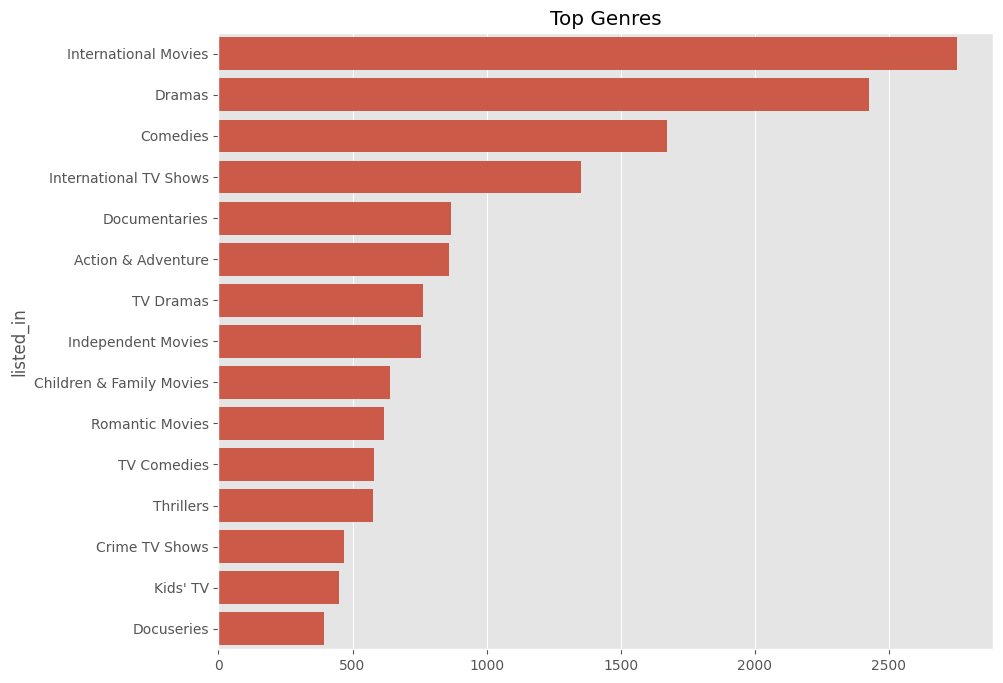

In [13]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(15)

plt.figure(figsize=(10,8))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top Genres")

plt.savefig("../images/07_genres.png", dpi=300)

plt.show()

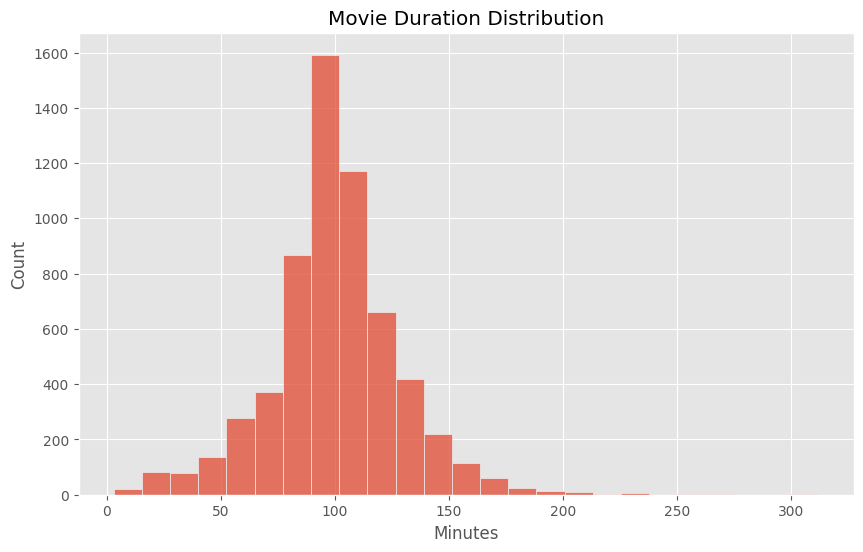

In [14]:
movies = df[df["type"]=="Movie"]

plt.figure(figsize=(10,6))

sns.histplot(
    movies["duration_number"],
    bins=25
)

plt.title("Movie Duration Distribution")

plt.xlabel("Minutes")

plt.savefig("../images/08_movie_duration.png", dpi=300)

plt.show()


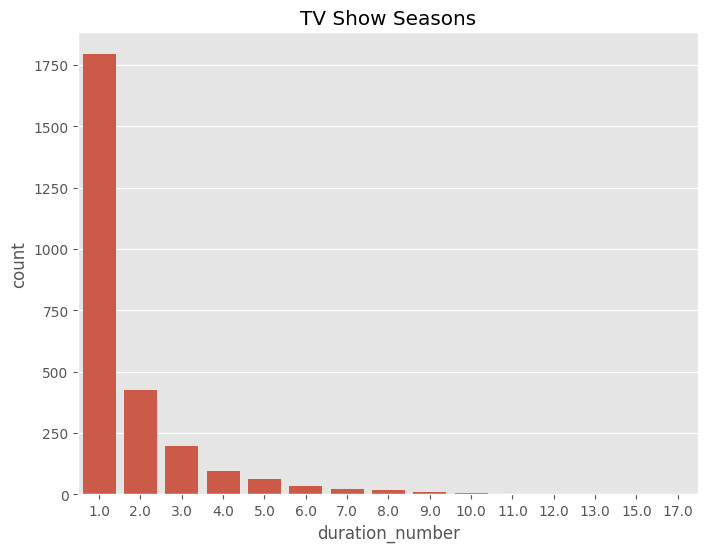

In [15]:
tv = df[df["type"]=="TV Show"]

plt.figure(figsize=(8,6))

sns.countplot(
    data=tv,
    x="duration_number"
)

plt.title("TV Show Seasons")

plt.savefig("../images/09_tv_seasons.png", dpi=300)

plt.show()

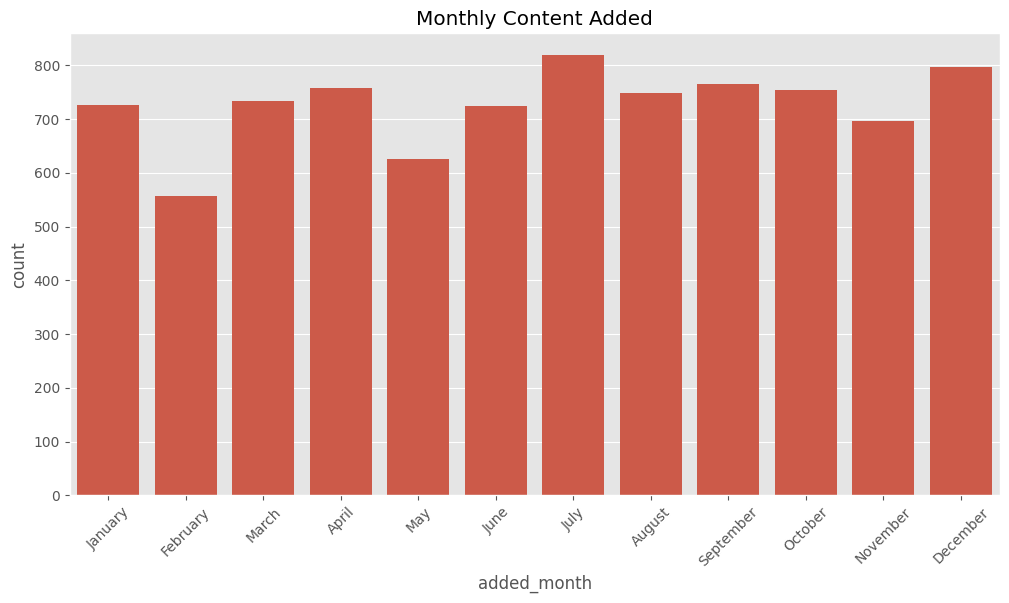

In [16]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="added_month",
    order=month_order
)

plt.xticks(rotation=45)

plt.title("Monthly Content Added")

plt.savefig("../images/10_monthly_added.png", dpi=300)

plt.show()

In [17]:
print("="*60)
print("NETFLIX DATA ANALYSIS REPORT")
print("="*60)

print(f"Total Titles      : {len(df)}")
print(f"Movies            : {len(df[df['type']=='Movie'])}")
print(f"TV Shows          : {len(df[df['type']=='TV Show'])}")
print(f"Countries         : {df['country'].nunique()}")
print(f"Directors         : {df['director'].nunique()}")
print(f"Genres            : {genres.nunique()}")

print("\nTop 10 Countries")

print(top_country)

print("\nTop Directors")

print(top_director)

print("\nTop Genres")

print(top_genres)

print("="*60)

NETFLIX DATA ANALYSIS REPORT
Total Titles      : 8807
Movies            : 6131
TV Shows          : 2676
Countries         : 749
Directors         : 4529
Genres            : 42

Top 10 Countries
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

Top Directors
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

Top Genres
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas   